✓ Libraries imported successfully!
✓ Data loaded: (1470, 48)
✓ Target variable: JobSatisfaction

Features shape: (1470, 47)
Target shape: (1470,)
Number of features: 47
TẠO TARGET MỚI TỪ HÀM QUYẾT ĐỊNH

Lớp được chọn: 4 (Very High Satisfaction)

--- LOGISTIC REGRESSION (Softmax Probability) ---
✓ Đã tạo target từ Softmax probability
  - Target shape: (1470,)
  - Target range: [0.0603, 0.6775]
  - Target mean: 0.3107
  - Target std: 0.0973

--- SVM (Decision Function) ---
✓ Đã tạo target từ SVM decision function
  - Target shape: (1470,)
  - Target range: [-0.2507, 3.2654]
  - Target mean: 2.4723
  - Target std: 0.8578


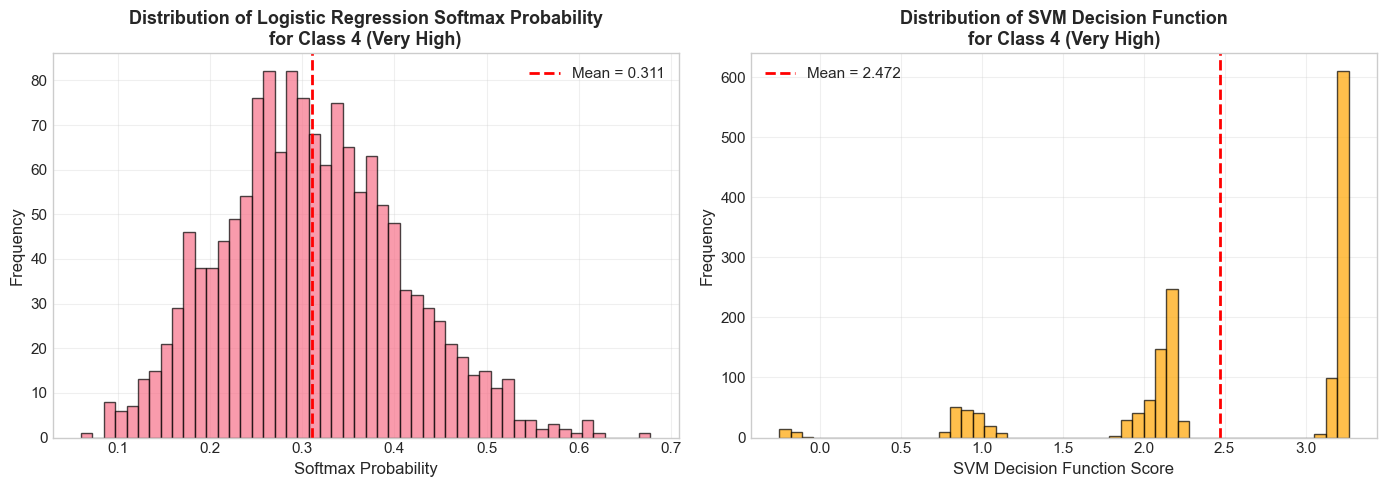


✓ Phân phối target đã được trực quan hóa

Số chiều gốc: 47
Số chiều sau giảm (1/3): 15
Phương sai giải thích: 0.6195
Tỉ lệ chia train:test:
  8:2
  7:3
  6:4
✓ Regression models imported!

CHẠY EXPERIMENTS - HỒI QUY TỪ HÀM QUYẾT ĐỊNH
Models được chọn: ['Ridge', 'MLP']

PHẦN 1: TARGET TỪ LOGISTIC REGRESSION (SOFTMAX)

--- Split ratio: 8:2 ---
  Training Ridge on Original data (LR Softmax)...
  Training MLP on Original data (LR Softmax)...
  Training Ridge on PCA Reduced data (LR Softmax)...
  Training MLP on PCA Reduced data (LR Softmax)...

--- Split ratio: 7:3 ---
  Training Ridge on Original data (LR Softmax)...
  Training MLP on Original data (LR Softmax)...
  Training Ridge on PCA Reduced data (LR Softmax)...
  Training MLP on PCA Reduced data (LR Softmax)...

--- Split ratio: 6:4 ---
  Training Ridge on Original data (LR Softmax)...
  Training MLP on Original data (LR Softmax)...
  Training Ridge on PCA Reduced data (LR Softmax)...
  Training MLP on PCA Reduced data (LR Softmax).

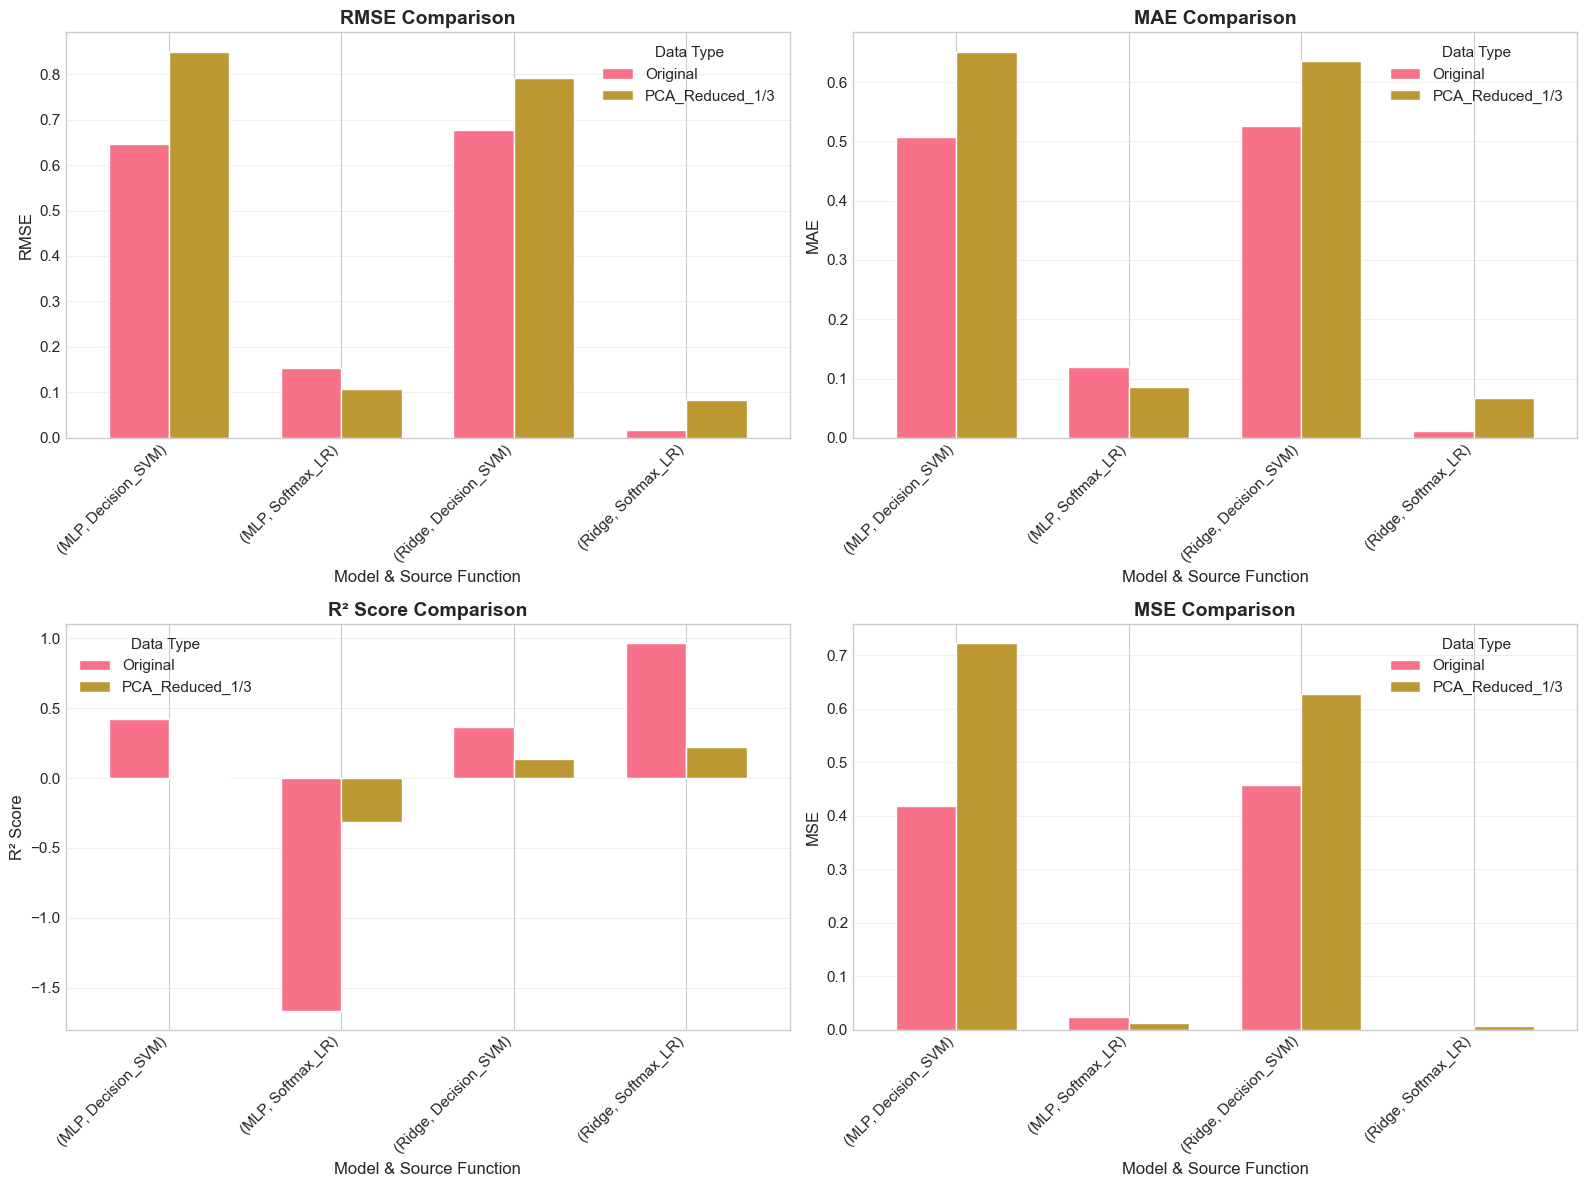

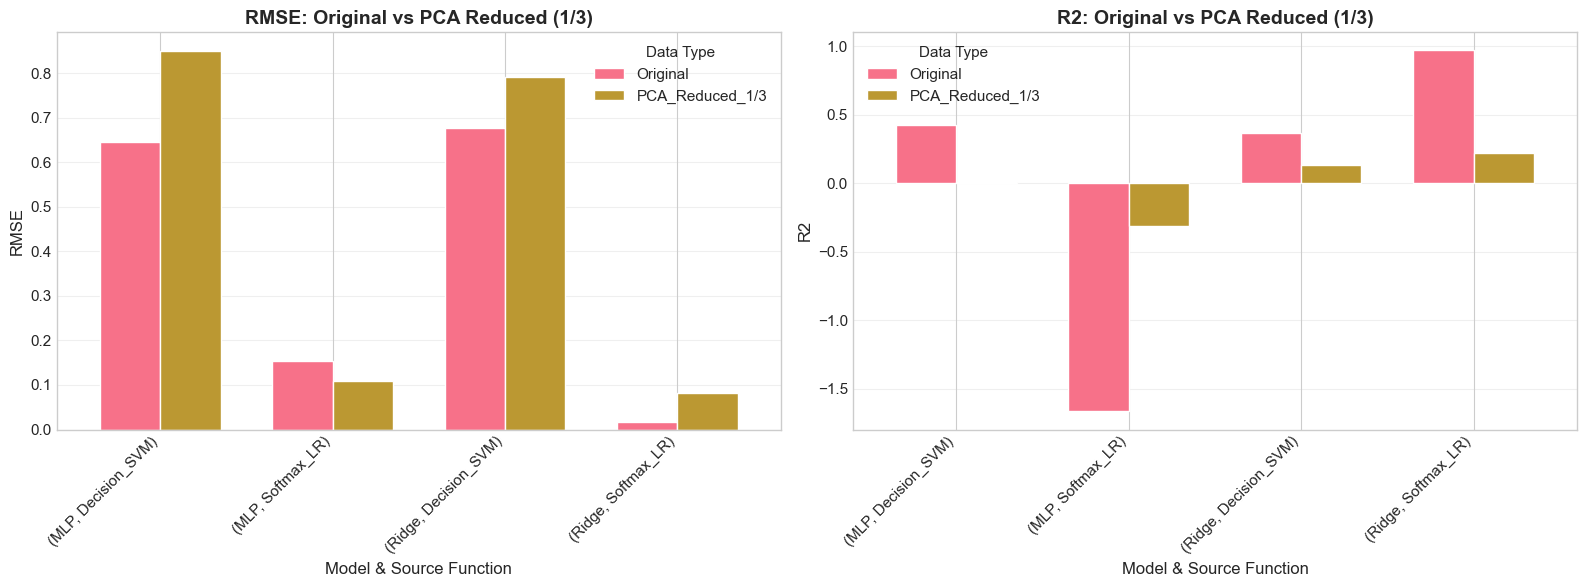


MÔ HÌNH TỐT NHẤT
Model: Ridge
Data Type: Original
Source Function: Softmax_LR
Split: 8:2
RMSE: 0.0155
R²: 0.9725


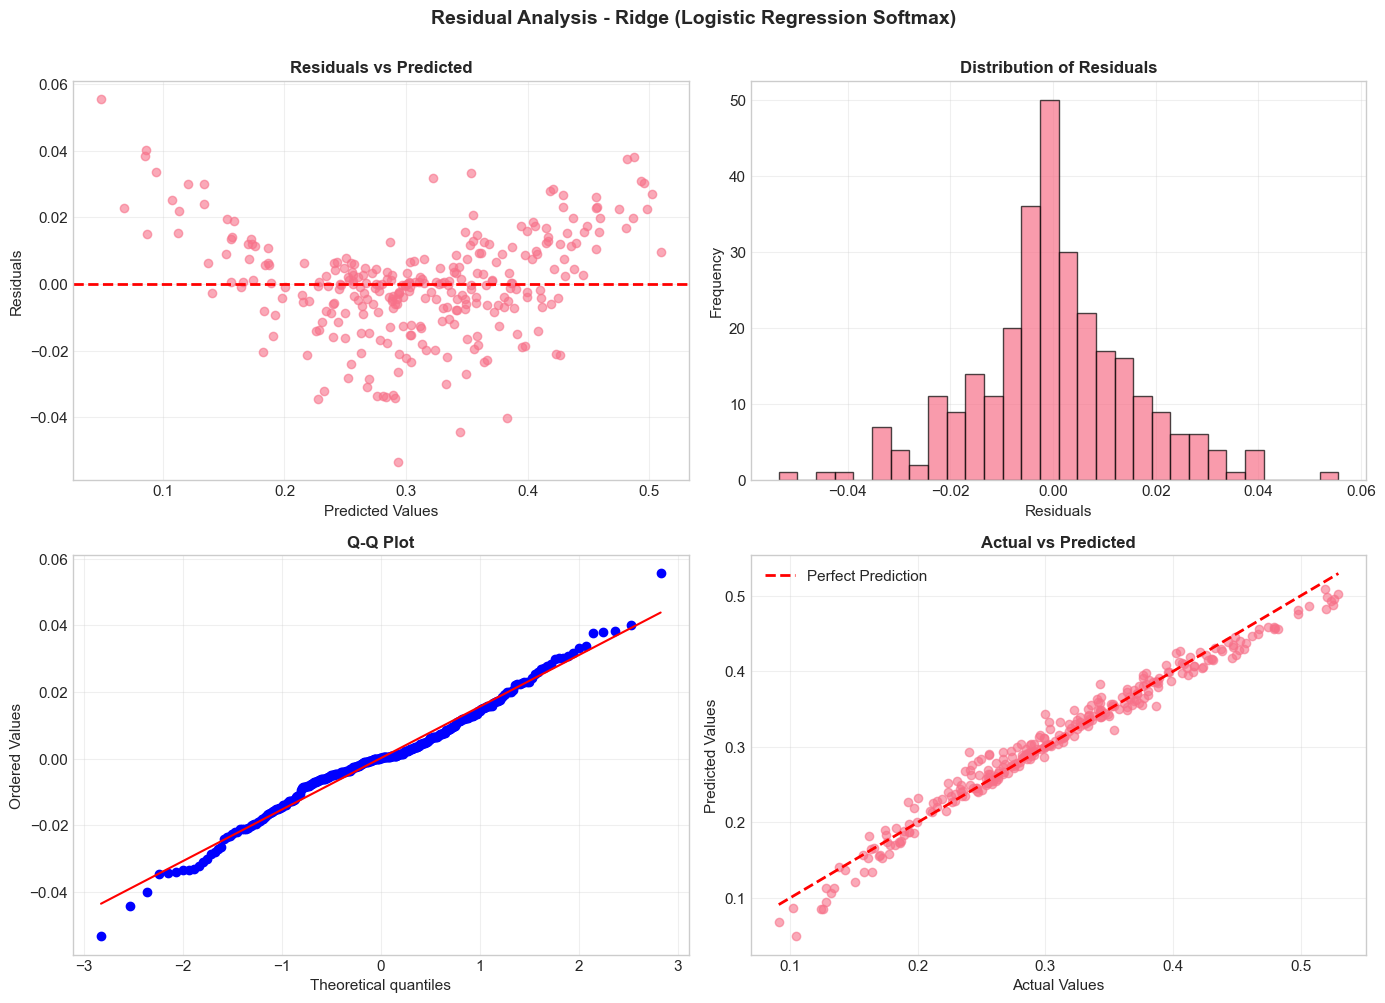


✓ Phân tích residuals hoàn tất!

SO SÁNH SOFTMAX VS SVM DECISION FUNCTION
                                           rmse       mae        r2
source_function model data_type                                    
Decision_SVM    MLP   Original         0.646359  0.507626  0.424336
                      PCA_Reduced_1/3  0.849528  0.651643  0.006240
                Ridge Original         0.676853  0.526799  0.368833
                      PCA_Reduced_1/3  0.792207  0.635866  0.135958
Softmax_LR      MLP   Original         0.153739  0.118938 -1.667341
                      PCA_Reduced_1/3  0.108040  0.085172 -0.313605
                Ridge Original         0.016182  0.011870  0.970531
                      PCA_Reduced_1/3  0.083093  0.066695  0.222884


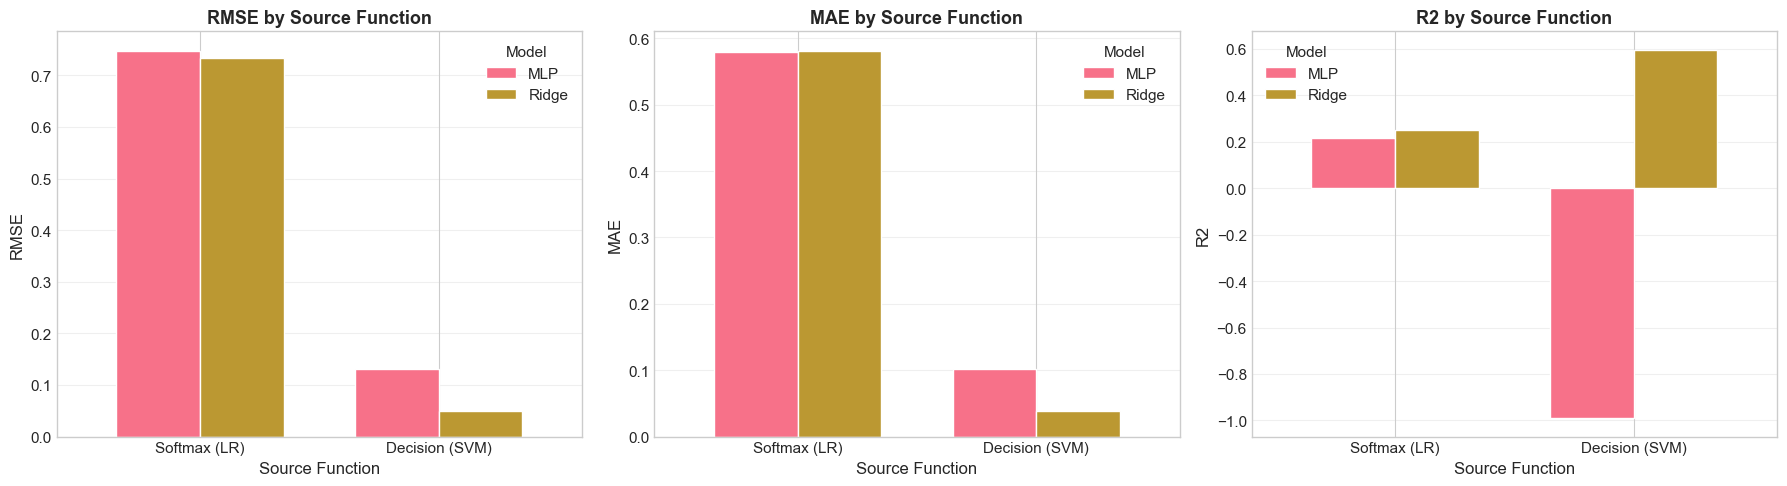


KẾT LUẬN

1. ĐÃ THỰC HIỆN:
   - Chuyển đổi bài toán phân loại sang hồi quy bằng 2 cách:
     + Sử dụng Softmax probability từ Logistic Regression
     + Sử dụng Decision Function từ SVM
   - Chọn lớp 4 (Very High Satisfaction) làm target
   - Áp dụng 2 mô hình hồi quy: Ridge và MLP
   - So sánh trên dữ liệu gốc và dữ liệu giảm về 1/3 số chiều
   - Đánh giá với 3 tỉ lệ train:test (4:1, 7:3, 6:4)

2. NHẬN XÉT VỀ SOFTMAX VS SVM:
   - Softmax probability có range [0, 1], phù hợp với xác suất
   - SVM decision function có range rộng hơn, phụ thuộc vào margin
   - So sánh R² và RMSE để đánh giá mô hình nào phù hợp hơn

3. NHẬN XÉT VỀ DỮ LIỆU GỐC VS GIẢM CHIỀU:
   - Dữ liệu giảm về 1/3 chiều có thể làm giảm overfitting
   - Trade-off giữa performance và complexity
   - Xem biểu đồ so sánh để đánh giá chi tiết

4. GIẢI THÍCH TẠI SAO:
   - Hàm quyết định cung cấp "confidence score" liên tục
   - Chuyển đổi từ classification sang regression hợp lý khi:
     + Muốn đánh giá mức độ "chắc chắn" củ

In [2]:
# NOTEBOOK 6: HỒI QUY TỪ HÀM QUYẾT ĐỊNH
# Yêu cầu 2.4(c)
# Chuyển bài toán phân loại sang hồi quy bằng cách sử dụng giá trị hàm quyết định

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully!")

## 1. LOAD DỮ LIỆU

import json

# Load data
df = pd.read_csv('../data/processed/data_normalized.csv')
print(f"✓ Data loaded: {df.shape}")

# Load metadata
with open('../data/processed/metadata.json', 'r') as f:
    metadata = json.load(f)

target_col = metadata['target_column']
print(f"✓ Target variable: {target_col}")

# Separate features and target
y_original = df[target_col].values  # JobSatisfaction gốc
X = df.drop(target_col, axis=1).values
feature_names = df.drop(target_col, axis=1).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y_original.shape}")
print(f"Number of features: {len(feature_names)}")

## 2. TẠO TARGET MỚI TỪ HÀM QUYẾT ĐỊNH
### Chọn 1 lớp cụ thể (lớp 4 - "Very High Satisfaction") và dùng probability/score làm target

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

print("=" * 80)
print("TẠO TARGET MỚI TỪ HÀM QUYẾT ĐỊNH")
print("=" * 80)

# Chọn lớp 4 (Very High Satisfaction) làm lớp quan tâm
target_class = 4
print(f"\nLớp được chọn: {target_class} (Very High Satisfaction)")

# Chuẩn bị dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dữ liệu ban đầu để train classifier
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_scaled, y_original, test_size=0.2, random_state=42, stratify=y_original
)

### 2.1. Sử dụng Logistic Regression (Softmax) để tạo target

print("\n--- LOGISTIC REGRESSION (Softmax Probability) ---")

# Train Logistic Regression với probability
lr_clf = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr_clf.fit(X_train_clf, y_train_clf)

# Lấy probability cho lớp 4
y_proba_lr = lr_clf.predict_proba(X_scaled)
class_index = np.where(lr_clf.classes_ == target_class)[0][0]
y_regression_lr = y_proba_lr[:, class_index]

print(f"✓ Đã tạo target từ Softmax probability")
print(f"  - Target shape: {y_regression_lr.shape}")
print(f"  - Target range: [{y_regression_lr.min():.4f}, {y_regression_lr.max():.4f}]")
print(f"  - Target mean: {y_regression_lr.mean():.4f}")
print(f"  - Target std: {y_regression_lr.std():.4f}")

### 2.2. Sử dụng SVM Decision Function để tạo target

print("\n--- SVM (Decision Function) ---")

# Train SVM với decision function
svm_clf = SVC(kernel='rbf', random_state=42, decision_function_shape='ovr')
svm_clf.fit(X_train_clf, y_train_clf)

# Lấy decision function cho lớp 4
y_decision_svm = svm_clf.decision_function(X_scaled)
if y_decision_svm.ndim > 1:
    class_index = np.where(svm_clf.classes_ == target_class)[0][0]
    y_regression_svm = y_decision_svm[:, class_index]
else:
    y_regression_svm = y_decision_svm

print(f"✓ Đã tạo target từ SVM decision function")
print(f"  - Target shape: {y_regression_svm.shape}")
print(f"  - Target range: [{y_regression_svm.min():.4f}, {y_regression_svm.max():.4f}]")
print(f"  - Target mean: {y_regression_svm.mean():.4f}")
print(f"  - Target std: {y_regression_svm.std():.4f}")

### 2.3. Trực quan hóa phân phối của target mới

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution của Softmax probability
axes[0].hist(y_regression_lr, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(y_regression_lr.mean(), color='r', linestyle='--', linewidth=2,
                label=f'Mean = {y_regression_lr.mean():.3f}')
axes[0].set_xlabel('Softmax Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Logistic Regression Softmax Probability\nfor Class 4 (Very High)',
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution của SVM decision function
axes[1].hist(y_regression_svm, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(y_regression_svm.mean(), color='r', linestyle='--', linewidth=2,
                label=f'Mean = {y_regression_svm.mean():.3f}')
axes[1].set_xlabel('SVM Decision Function Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of SVM Decision Function\nfor Class 4 (Very High)',
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/target_distribution_decision_functions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Phân phối target đã được trực quan hóa")

## 3. CHUẨN BỊ DỮ LIỆU GIẢM CHIỀU (1/3 SỐ CHIỀU)

# Giảm về 1/3 số chiều như yêu cầu
n_components_reduced = X.shape[1] // 3
print(f"\nSố chiều gốc: {X.shape[1]}")
print(f"Số chiều sau giảm (1/3): {n_components_reduced}")

pca_reduced = PCA(n_components=n_components_reduced, random_state=42)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

variance_explained = pca_reduced.explained_variance_ratio_.sum()
print(f"Phương sai giải thích: {variance_explained:.4f}")

## 4. ĐỊNH NGHĨA TỈ LỆ CHIA DỮ LIỆU

train_test_splits = [
    (0.8, 0.2),  # 4:1
    (0.7, 0.3),  # 7:3
    (0.6, 0.4)  # 6:4
]

print("Tỉ lệ chia train:test:")
for train_size, test_size in train_test_splits:
    print(f"  {int(train_size * 10)}:{int(test_size * 10)}")

## 5. IMPORT MÔ HÌNH HỒI QUY

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor

print("✓ Regression models imported!")


## 6. HÀM TRAIN VÀ ĐÁNH GIÁ HỒI QUY

def train_and_evaluate_regression(X_train, X_test, y_train, y_test,
                                  model_name, data_type, split_ratio,
                                  source_function, results_dict):
    """
    Train và evaluate regression model
    """
    # Khởi tạo models
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0, random_state=42),
        'Lasso': Lasso(alpha=0.01, random_state=42, max_iter=5000),
        'KNN': KNeighborsRegressor(n_neighbors=5),
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
        'MLP': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
    }

    model = models[model_name]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Lưu kết quả
    results_dict['split'].append(split_ratio)
    results_dict['model'].append(model_name)
    results_dict['data_type'].append(data_type)
    results_dict['source_function'].append(source_function)
    results_dict['mse'].append(mse)
    results_dict['rmse'].append(rmse)
    results_dict['mae'].append(mae)
    results_dict['r2'].append(r2)

    return model, y_pred


## 7. CHẠY EXPERIMENTS

# Dictionary lưu kết quả
results_regression = {
    'split': [],
    'model': [],
    'data_type': [],
    'source_function': [],
    'mse': [],
    'rmse': [],
    'mae': [],
    'r2': []
}

# Chọn 2 models hồi quy như yêu cầu
selected_regression_models = ['Ridge', 'MLP']

print("\n" + "=" * 80)
print("CHẠY EXPERIMENTS - HỒI QUY TỪ HÀM QUYẾT ĐỊNH")
print("=" * 80)
print(f"Models được chọn: {selected_regression_models}")

# ==============================================================================
# PHẦN 1: HỒI QUY TỪ LOGISTIC REGRESSION (SOFTMAX PROBABILITY)
# ==============================================================================
print("\n" + "=" * 80)
print("PHẦN 1: TARGET TỪ LOGISTIC REGRESSION (SOFTMAX)")
print("=" * 80)

for train_size, test_size in train_test_splits:
    split_ratio = f"{int(train_size * 10)}:{int(test_size * 10)}"
    print(f"\n--- Split ratio: {split_ratio} ---")

    # ===== DỮ LIỆU GỐC =====
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_regression_lr, test_size=test_size, random_state=42
    )

    for model_name in selected_regression_models:
        print(f"  Training {model_name} on Original data (LR Softmax)...")
        train_and_evaluate_regression(
            X_train, X_test, y_train, y_test,
            model_name, 'Original', split_ratio, 'Softmax_LR', results_regression
        )

    # ===== DỮ LIỆU GIẢM CHIỀU =====
    X_train_pca, X_test_pca, y_train, y_test = train_test_split(
        X_pca_reduced, y_regression_lr, test_size=test_size, random_state=42
    )

    for model_name in selected_regression_models:
        print(f"  Training {model_name} on PCA Reduced data (LR Softmax)...")
        train_and_evaluate_regression(
            X_train_pca, X_test_pca, y_train, y_test,
            model_name, 'PCA_Reduced_1/3', split_ratio, 'Softmax_LR', results_regression
        )

# ==============================================================================
# PHẦN 2: HỒI QUY TỪ SVM (DECISION FUNCTION)
# ==============================================================================
print("\n" + "=" * 80)
print("PHẦN 2: TARGET TỪ SVM (DECISION FUNCTION)")
print("=" * 80)

for train_size, test_size in train_test_splits:
    split_ratio = f"{int(train_size * 10)}:{int(test_size * 10)}"
    print(f"\n--- Split ratio: {split_ratio} ---")

    # ===== DỮ LIỆU GỐC =====
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_regression_svm, test_size=test_size, random_state=42
    )

    for model_name in selected_regression_models:
        print(f"  Training {model_name} on Original data (SVM Decision)...")
        train_and_evaluate_regression(
            X_train, X_test, y_train, y_test,
            model_name, 'Original', split_ratio, 'Decision_SVM', results_regression
        )

    # ===== DỮ LIỆU GIẢM CHIỀU =====
    X_train_pca, X_test_pca, y_train, y_test = train_test_split(
        X_pca_reduced, y_regression_svm, test_size=test_size, random_state=42
    )

    for model_name in selected_regression_models:
        print(f"  Training {model_name} on PCA Reduced data (SVM Decision)...")
        train_and_evaluate_regression(
            X_train_pca, X_test_pca, y_train, y_test,
            model_name, 'PCA_Reduced_1/3', split_ratio, 'Decision_SVM', results_regression
        )

print("\n✓ All experiments completed!")

## 8. HIỂN THỊ KẾT QUẢ

# Tạo DataFrame kết quả
results_df = pd.DataFrame(results_regression)

print("\n" + "=" * 80)
print("KẾT QUẢ HỒI QUY TỪ HÀM QUYẾT ĐỊNH")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Tính trung bình
print("\n--- Trung bình theo Model, Data Type và Source Function ---")
avg_results = results_df.groupby(['model', 'data_type', 'source_function'])[
    ['rmse', 'mae', 'r2']].mean()
print(avg_results)

## 9. TRỰC QUAN HÓA KẾT QUẢ

# So sánh theo Source Function (Softmax vs SVM)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['rmse', 'mae', 'r2', 'mse']
metric_labels = ['RMSE', 'MAE', 'R² Score', 'MSE']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 2, idx % 2]

    pivot_table = results_df.pivot_table(
        values=metric,
        index=['model', 'source_function'],
        columns=['data_type'],
        aggfunc='mean'
    )

    pivot_table.plot(kind='bar', ax=ax, width=0.7)
    ax.set_title(f'{label} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('Model & Source Function', fontsize=12)
    ax.legend(title='Data Type', loc='best')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../results/regression_from_decision_function.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. SO SÁNH DỮ LIỆU GỐC VS GIẢM CHIỀU

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# So sánh RMSE
for idx, metric in enumerate(['rmse', 'r2']):
    ax = axes[idx]
    comparison_data = results_df.groupby(['model', 'source_function', 'data_type'])[metric].mean().unstack()
    comparison_data.plot(kind='bar', ax=ax, width=0.7)
    ax.set_title(f'{metric.upper()}: Original vs PCA Reduced (1/3)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_xlabel('Model & Source Function', fontsize=12)
    ax.legend(title='Data Type')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../results/original_vs_pca_regression.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. PHÂN TÍCH RESIDUALS CHO MÔ HÌNH TỐT NHẤT

# Tìm mô hình tốt nhất dựa trên R²
best_idx = results_df['r2'].idxmax()
best_config = results_df.iloc[best_idx]

print("\n" + "=" * 80)
print("MÔ HÌNH TỐT NHẤT")
print("=" * 80)
print(f"Model: {best_config['model']}")
print(f"Data Type: {best_config['data_type']}")
print(f"Source Function: {best_config['source_function']}")
print(f"Split: {best_config['split']}")
print(f"RMSE: {best_config['rmse']:.4f}")
print(f"R²: {best_config['r2']:.4f}")
print("=" * 80)

# Train lại mô hình tốt nhất
if best_config['source_function'] == 'Softmax_LR':
    y_target = y_regression_lr
    source_name = "Logistic Regression Softmax"
else:
    y_target = y_regression_svm
    source_name = "SVM Decision Function"

if best_config['data_type'] == 'Original':
    X_data = X_scaled
else:
    X_data = X_pca_reduced

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_target, test_size=0.2, random_state=42
)

# Train model
if best_config['model'] == 'Ridge':
    best_model = Ridge(alpha=1.0, random_state=42)
elif best_config['model'] == 'MLP':
    best_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

residuals = y_test - y_pred

# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_pred, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot
from scipy import stats

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred, alpha=0.6)
axes[1, 1].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Values', fontsize=11)
axes[1, 1].set_ylabel('Predicted Values', fontsize=11)
axes[1, 1].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle(f'Residual Analysis - {best_config["model"]} ({source_name})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/residual_analysis_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Phân tích residuals hoàn tất!")

## 12. SO SÁNH SOFTMAX VS SVM DECISION FUNCTION

print("\n" + "=" * 80)
print("SO SÁNH SOFTMAX VS SVM DECISION FUNCTION")
print("=" * 80)

comparison = results_df.groupby(['source_function', 'model', 'data_type'])[
    ['rmse', 'mae', 'r2']].mean()
print(comparison)

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, metric in enumerate(['rmse', 'mae', 'r2']):
    ax = axes[idx]

    comparison_data = results_df.groupby(['source_function', 'model'])[metric].mean().unstack()
    comparison_data.plot(kind='bar', ax=ax, width=0.7)
    ax.set_title(f'{metric.upper()} by Source Function', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_xlabel('Source Function', fontsize=12)
    ax.legend(title='Model')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(['Softmax (LR)', 'Decision (SVM)'], rotation=0)

plt.tight_layout()
plt.savefig('../results/softmax_vs_svm_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. KẾT LUẬN VÀ GIẢI THÍCH

print("\n" + "=" * 80)
print("KẾT LUẬN")
print("=" * 80)

print("""
1. ĐÃ THỰC HIỆN:
   - Chuyển đổi bài toán phân loại sang hồi quy bằng 2 cách:
     + Sử dụng Softmax probability từ Logistic Regression
     + Sử dụng Decision Function từ SVM
   - Chọn lớp 4 (Very High Satisfaction) làm target
   - Áp dụng 2 mô hình hồi quy: Ridge và MLP
   - So sánh trên dữ liệu gốc và dữ liệu giảm về 1/3 số chiều
   - Đánh giá với 3 tỉ lệ train:test (4:1, 7:3, 6:4)

2. NHẬN XÉT VỀ SOFTMAX VS SVM:
   - Softmax probability có range [0, 1], phù hợp với xác suất
   - SVM decision function có range rộng hơn, phụ thuộc vào margin
   - So sánh R² và RMSE để đánh giá mô hình nào phù hợp hơn

3. NHẬN XÉT VỀ DỮ LIỆU GỐC VS GIẢM CHIỀU:
   - Dữ liệu giảm về 1/3 chiều có thể làm giảm overfitting
   - Trade-off giữa performance và complexity
   - Xem biểu đồ so sánh để đánh giá chi tiết

4. GIẢI THÍCH TẠI SAO:
   - Hàm quyết định cung cấp "confidence score" liên tục
   - Chuyển đổi từ classification sang regression hợp lý khi:
     + Muốn đánh giá mức độ "chắc chắn" của prediction
     + Cần giá trị liên tục thay vì nhãn rời rạc
   - Giảm chiều giúp:
     + Giảm computational cost
     + Có thể cải thiện generalization
     + Loại bỏ noise và redundant features

5. ỨNG DỤNG THỰC TẾ:
   - Ranking nhân viên theo "mức độ hài lòng dự đoán"
   - Phát hiện các trường hợp "borderline" (score gần threshold)
   - Hỗ trợ ra quyết định dựa trên confidence level
""")